In [ ]:
#!pip install lifelines
#!pip install EMP-PY
#!pip install interpret
#!pip install sklearn-genetic-opt
#!pip install seaborn
#!pip install hyperparameter-optimizer
#!pip install pyswarms
#!pip install optuna
#!pip install pymoo

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/72.7 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/72.7 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/72.7 kB ? eta -:--:--
     --------------------- ---------------- 41.0/72.7 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 72.7/72.7 kB 672.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   -- ------------------------------------- 0.1/1.8 MB 5.5 MB/s eta 0:00:01
   ---- ----------------------------------- 0.2/1.8 MB 2.5 MB/s eta 0:00:01
   ------ --------------------------------- 0.3/1.8 MB 2.7 MB/s eta 0:00:01
   --------- ------------------------------ 0.4/1.8 MB 2.6 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/1.8 MB 2.5 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/1.8 MB 2.5 MB/s eta 0:00:01
   -------------- -


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


EDA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


Series([], dtype: float64)

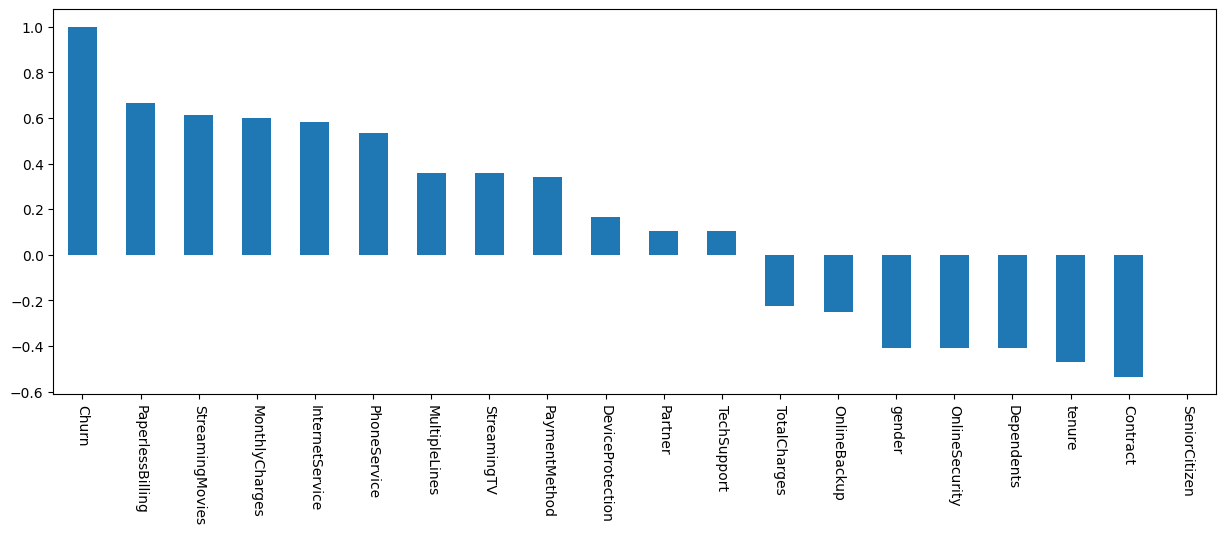

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn import metrics
import time, datetime
warnings.filterwarnings('ignore')
from IPython.display import display, Markdown
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
import random

df = pd.read_csv('IBM.csv')

"""
To train the model on only fraction of the dataset :
Just for testing purposes, command the below line to actually train the model properly.

df = df.sample(frac=0.001) # Dataset of  Subsample size 70 .

"""



# REQUIREMENT: df must be defined before running this file
if 'df' not in globals():
    raise RuntimeError('df is not defined. Load your dataset into a DataFrame named df before running this file.')


class_names = [0, 1]
_class = 'Churn'
df.drop(['customerID'], axis=1, inplace=True)
df.isnull().sum()
# Check our target column
df[_class].value_counts()

# List the columns that contain "No internet service" to convert this value to "No"
tobe_cleaned_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df[tobe_cleaned_cols] = df[tobe_cleaned_cols].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

# Convert the datatype of the TotalCharge column to be float
# it seems that this column contains an empty string, so we need to deal with it before converting
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")

# Now we can convert it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

from sklearn.preprocessing import LabelEncoder

# Encoding categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])

def remove_missing_values(df):
    for x in df.columns:
        if df[x].isnull().sum() != 0:
            print(x, df[x].isnull().sum())

    return df.dropna()

df = remove_missing_values(df).reset_index(drop=True)
df.info()

# List of categoricals

def list_categoricals(df):
    categoricals = list()
    for x in df.columns:
        if df[x].dtype == 'object':
            categoricals.append(x)
    display(df[categoricals].nunique())
    return categoricals

categoricals = list_categoricals(df)

numericals = [x for x in df.columns if x not in categoricals]

plt.figure(figsize=(15,5))
plt.grid(True)
df[numericals].head(10).corr()[_class].sort_values(ascending = False).plot(kind='bar')
plt.xticks(rotation=-90)
plt.show()

df = pd.get_dummies(df, drop_first=True)

# Calculate customer value [Estimated by Atif]
df['customer_value'] = df['MonthlyCharges'] * df['tenure'].apply(lambda x: x+1) # plus 1 month in tenure
#df['customer_value'] = df['MonthlyCharges'] * df['tenure']

tenure_column = 'tenure'

df[['MonthlyCharges', 'tenure', 'customer_value']].sort_values(by=['customer_value'], ascending=True).head(n=15)

# these are all monthly charges

df.shape

df.info()

X, y = df.drop(columns=[_class]), df[_class]
random_state = 42

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=random_state)

x_test.shape

x_train.shape

x_train.info()

(4930,) (4930,)


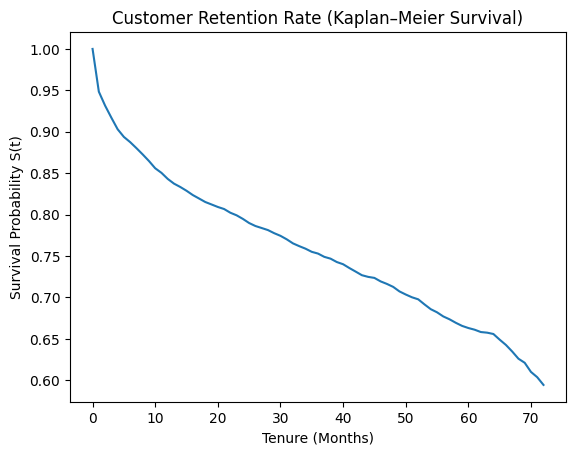

ARR(Δ=1.0): 0.992197
0.855923398940697


In [22]:
# ===================== IMPORTS =====================
from lifelines import KaplanMeierFitter
from EMP.metrics import empChurn
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np

# ===================== CUSTOM METRICS =====================
# Survival Analysis: Kaplan-Meier estimator used to model time-to-churn and estimate retention.

def conditional_retention(retention_fn, tenure, delta=1.0, eps=1e-12):
    ten = np.asarray(tenure, dtype=float)
    S_t = np.asarray(retention_fn(ten), dtype=float)
    S_t_delta = np.asarray(retention_fn(ten + delta), dtype=float)
    return S_t_delta / np.maximum(S_t, eps)


def get_retention_rate(x_train, y_train, tenure_column, delta=1.0):
    tenure = x_train[tenure_column].values.astype(float)
    event_observed = (y_train == 1).astype(int).values

    print(tenure.shape, event_observed.shape)

    # Kaplan-Meier Estimator
    kmf = KaplanMeierFitter()
    kmf.fit(tenure, event_observed=event_observed)

    # Plot the survival function (keep as you had it)
    plt.plot(kmf.survival_function_)
    plt.title('Customer Retention Rate (Kaplan–Meier Survival)')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Survival Probability S(t)')
    plt.show()

    # Survival function S(t)
    def S(t):
        t_arr = np.atleast_1d(np.asarray(t, dtype=float))
        vals = kmf.survival_function_at_times(t_arr).values
        return float(vals[0]) if np.isscalar(t) else vals


    # Compute TRR_i(Δ) for all training customers and take mean => ARR(Δ)
    trr_train = conditional_retention(S, tenure, delta=delta)
    arr_train = float(np.mean(trr_train))

    print(f'ARR(Δ={delta}): {arr_train:.6f}')
    return arr_train, S


# --- Preserve your variable names exactly ---
DELTA = 1.0  # if tenure is months set 1; if tenure is days set 30
avg_retention_rate, retention_fn = get_retention_rate(x_train, y_train, tenure_column, delta=DELTA)

print(retention_fn(10))  # prints S(10)
f'Average Retention Rate {avg_retention_rate: .2f}'


def estimate_clv_and_cost_of_intervention(df, i, Profit_Margin=0.3, CPO=0.1):
    # Estimate of CLV: (monthly_revenue * Profit_Margin) / (1 - retention_rate)
    monthly_revenue = df.iloc[i]['customer_value']
    retention_rate = min(0.995, df.iloc[i]['retention_rate'])  # retention rate can never be 1
    clv = (monthly_revenue * Profit_Margin) / (1 - retention_rate)

    # Cost of intervention is CPO * CLV
    base_cost = CPO * clv
    cost_per_offer = base_cost
    return clv, cost_per_offer


# Our Metric calculation function
def _eprofits(df, Profit_Margin, Cost_of_Contact, CPO, verbose=0):
    profits = []
    for i in range(len(df)):
        clv, cost_per_offer = estimate_clv_and_cost_of_intervention(df, i, Profit_Margin, CPO)
        cost_of_contact = max(Cost_of_Contact[0], Cost_of_Contact[1] * cost_per_offer)

        if df.iloc[i]['true'] == 1 and df.iloc[i]['predict'] == df.iloc[i]['true']:  # churners predicted as churners
            profit = clv - cost_per_offer - cost_of_contact
            if verbose:
                print(profit, i, df.iloc[i]['true'], df.iloc[i]['predict'])

        elif df.iloc[i]['predict'] == 1:  # non-churners predicted as churners
            profit = -cost_per_offer - cost_of_contact
            if verbose:
                print(profit, i, df.iloc[i]['true'], df.iloc[i]['predict'])

        else:
            profit = 0  # no intervention
        profits.append(profit)

    return sum(profits)


Profit_Margin = 0.3
Cost_of_Contact = (0, 0.3)
CPO = 0.1


def custom_eprofits_scorer_tenure(
    df, tenure_column, retention_fn, delta,
    Profit_Margin, Cost_of_Contact, CPO, threshold=0.5
):
    def scorer(estimator, X, y):
        y_scores = estimator.predict_proba(X)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

        my_df = df.loc[y.index].copy()

        ten = my_df[tenure_column].astype(float).values
        my_df["retention_rate"] = conditional_retention(retention_fn, ten, delta=delta)

        my_df["true"] = np.asarray(y)
        my_df["predict"] = y_pred
        return _eprofits(my_df, Profit_Margin, Cost_of_Contact, CPO)

    return scorer

def custom_eprofits_scorer_avg(
    df, avg_retention_rate,
    Profit_Margin, Cost_of_Contact, CPO, threshold=0.5
):
    def scorer(estimator, X, y):
        y_scores = estimator.predict_proba(X)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

        my_df = df.loc[y.index].copy()

        # everyone gets the same retention rate ARR(Δ)
        my_df["retention_rate"] = float(avg_retention_rate)

        my_df["true"] = np.asarray(y)
        my_df["predict"] = y_pred
        return _eprofits(my_df, Profit_Margin, Cost_of_Contact, CPO)

    return scorer



# Define the EMP scorer function
def emp_scorer(estimator, X, y):
    # predict probabilities
    y_proba = estimator.predict_proba(X)[:, 1]
    return empChurn(
        y_proba, y,
        alpha=6, beta=14,
        clv=200, d=10, f=1,
        print_output=False,
        return_output=True,
        rounding=None
    ).EMP

# already computed earlier
# avg_retention_rate, retention_fn = get_retention_rate(delta=DELTA)

eprofits_scorer_train_tenure = custom_eprofits_scorer_tenure(
    df=x_train,
    tenure_column=tenure_column,
    retention_fn=retention_fn,
    delta=DELTA,
    Profit_Margin=Profit_Margin,
    Cost_of_Contact=Cost_of_Contact,
    CPO=CPO,
    threshold=0.5
)

eprofits_scorer_train_avg = custom_eprofits_scorer_avg(
    df=x_train,
    avg_retention_rate=avg_retention_rate,
    Profit_Margin=Profit_Margin,
    Cost_of_Contact=Cost_of_Contact,
    CPO=CPO,
    threshold=0.5
)

In [ ]:
import pandas as pd
import sklearn.metrics as metrics
import datetime
import time
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
# from Metrics_profitability import _eprofits, empChurn
# from Tabnet_training import tabnet_results_by_policy


# ===================== PARAMETER GRIDS =====================
auc_scorer = metrics.make_scorer(metrics.roc_auc_score, needs_proba=True)



cv = 5

#I have used Categorical([values]) to avoid an error. Gemini told me to use Categorical so I do not know if it has messed with the values.
# Please run the code and check for the output.

param_grid_ebm = {
    'learning_rate': Categorical([0.01,0.05,0.1]),
    'max_bins': Categorical([128, 256 ]),
    'max_interaction_bins': Categorical([16, 32]),
    'interactions': Categorical([10, 20])
}


# ===================== MODEL INITIALIZATION =====================

ebm = ExplainableBoostingClassifier(random_state=random_state)


ebm_with_grids = [
    (ebm, param_grid_ebm, 'ebm'),
]


Metrics_to_hypertune_for = {
   "AUC": 'roc_auc',
    "accuracy": metrics.make_scorer(metrics.accuracy_score),
    "f1": metrics.make_scorer(metrics.f1_score),
    "emp": emp_scorer,
    "eprofits_avg": eprofits_scorer_train_avg,
    "eprofits_tenure": eprofits_scorer_train_tenure,
}



def genetic_search(model, param_grid, x, y, cv, scoring, refit=True, verbose=None, _name=None):
    if refit == 'emp':
        n_jobs = 1
    else:
        n_jobs = -1
    now = datetime.datetime.now()
    if _name:
        print(_name.title(), 'at', now)
    else:
        print('At', now)
    start = time.time()

    if verbose:
        gs = GASearchCV(estimator=model, param_grid=param_grid, cv=cv,population_size=50,generations=80,tournament_size=5,elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.11,algorithm='eaMuPlusLambda',criteria='max',
                          scoring=scoring, refit=refit, n_jobs=n_jobs, verbose=verbose,keep_top_k=4)
    else:
         gs = GASearchCV(estimator=model, param_grid=param_grid, cv=cv,population_size=50,generations=80,tournament_size=5,elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.1,algorithm='eaMuPlusLambda',criteria='max',
                          scoring=scoring, refit=refit, n_jobs=n_jobs,keep_top_k=4)
    gs.fit(x, y)
    taken = time.time() - start
    gs.fit_time_ = taken  # Creating a custom object for grid search known as fit_time_
    print(f' > done; taken {taken:.2f}')
    return gs

genetic_search_results = {}


def genetic_search_driver(Metrics_to_hypertune_for):
    for Metric_name, Metric_function in Metrics_to_hypertune_for.items():
        _scoring = {Metric_name: Metric_function}
        refit = Metric_name

        print('With scoring', Metric_name)
        for classifier, param_grid, name_of_model in ebm_with_grids:
            if name_of_model not in genetic_search_results:
                genetic_search_results[name_of_model] = {}
            genetic_search_results[name_of_model][Metric_name] = genetic_search(
                classifier, param_grid, x_train, y_train, cv, _scoring, refit, verbose=1, _name=name_of_model
            )
    return genetic_search_results

genetic_search_results = genetic_search_driver(Metrics_to_hypertune_for)



With scoring AUC
Ebm at 2026-05-07 00:05:16.718666
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	50    	0.844156	0.000746182	0.845162   	0.84281    
1  	88    	0.845002	0.000239986	0.845162   	0.844394   
2  	92    	0.845149	1.81081e-05	0.845162   	0.845106   
3  	91    	0.845161	4.08937e-06	0.845162   	0.845132   
4  	92    	0.845162	7.77156e-16	0.845162   	0.845162   
5  	90    	0.845162	7.77156e-16	0.845162   	0.845162   
6  	88    	0.845162	7.77156e-16	0.845162   	0.845162   
7  	90    	0.845162	7.77156e-16	0.845162   	0.845162   
8  	94    	0.845162	7.77156e-16	0.845162   	0.845162   
9  	93    	0.845162	7.77156e-16	0.845162   	0.845162   
10 	96    	0.845162	7.77156e-16	0.845162   	0.845162   
11 	95    	0.845162	7.77156e-16	0.845162   	0.845162   
12 	91    	0.845162	7.77156e-16	0.845162   	0.845162   
13 	91    	0.845162	7.77156e-16	0.845162   	0.845162   
14 	92    	0.845162	7.77156e-16	0.845162   	0.845162   
15 	90    	0.845162	7.77156e-16	0.845162   	0.845162 

KeyboardInterrupt: 

Predicting based on the last metric(e_profits_tenure) hyperparameter results 


In [23]:
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
from scipy import stats

def predict(x_test,y_test,fitted_model):

    y_pred = fitted_model.predict(x_test)
    accuracy_score(y_test,y_pred)

# Please do not change the y_pred line
y_pred = genetic_search_results['ebm']['eprofits_tenure'].predict(x_test)
accuracy = (y_pred,y_test)
f1 = metrics.f1_score(y_test,y_pred)
print(f1)



NameError: name 'genetic_search_results' is not defined

In [34]:
import optuna
import sklearn.model_selection
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

def objective(trial):
    classifier = trial.suggest_categorical('classifier',['ExplainableBoostingClassifier'])
    learning_rate = trial.suggest_float('learning_rate',0.01,0.1)
    max_bins = trial.suggest_int('max_bins',128,256)
    max_interaction_bins = trial.suggest_int('max_interaction_bins',16,32)
    interactions = trial.suggest_int('interactions',10,20)
    clf  = ExplainableBoostingClassifier(learning_rate=learning_rate,max_bins=max_bins,max_interaction_bins=max_interaction_bins,interactions=interactions)
    fitted  = clf.fit(x_train,y_train)

    y_pred = fitted.predict(x_test) 
    y_proba= fitted.predict_proba(x_test)[:,1]

    accuracy = accuracy_score(y_test,y_pred) 
    f1 = f1_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_proba)
    emp = emp_scorer(fitted,x_test,y_test)
    eprofits_avg = eprofits_scorer_train_avg(fitted,X,y),
    eprofits_tenure = eprofits_scorer_train_tenure(fitted,X,y),
    

    
   
    return accuracy,f1,auc,emp,eprofits_avg,eprofits_tenure

study = optuna.create_study(directions=['maximize','maximize','maximize','maximize','maximize','maximize'])
study.optimize(objective, n_trials=100)



[I 2026-05-09 00:26:06,879] A new study created in memory with name: no-name-ff272907-7b28-4dea-a62e-09bb8ee7a430
[W 2026-05-09 00:26:08,046] Trial 0 failed with parameters: {'classifier': 'ExplainableBoostingClassifier', 'learning_rate': 0.02245890465197708, 'max_bins': 148, 'max_interaction_bins': 20, 'interactions': 14} because of the following error: KeyError('[8, 14, 15, 17, 19, 23, 26, 29, 31, 33, 37, 41, 44, 45, 50, 51, 57, 59, 61, 63, 65, 69, 71, 73, 75, 79, 80, 84, 87, 88, 90, 91, 93, 95, 96, 100, 101, 102, 106, 107, 108, 110, 121, 122, 124, 132, 135, 142, 144, 149, 151, 156, 157, 167, 168, 169, 172, 176, 177, 179, 181, 183, 184, 185, 188, 196, 198, 199, 208, 210, 216, 217, 221, 227, 228, 230, 231, 233, 239, 240, 245, 247, 248, 251, 252, 254, 257, 259, 263, 265, 268, 272, 279, 286, 290, 291, 292, 293, 296, 297, 303, 307, 308, 315, 318, 319, 321, 322, 323, 324, 325, 332, 333, 334, 336, 339, 344, 346, 347, 349, 351, 354, 367, 371, 373, 376, 378, 380, 381, 387, 393, 401, 408, 410

KeyError: '[8, 14, 15, 17, 19, 23, 26, 29, 31, 33, 37, 41, 44, 45, 50, 51, 57, 59, 61, 63, 65, 69, 71, 73, 75, 79, 80, 84, 87, 88, 90, 91, 93, 95, 96, 100, 101, 102, 106, 107, 108, 110, 121, 122, 124, 132, 135, 142, 144, 149, 151, 156, 157, 167, 168, 169, 172, 176, 177, 179, 181, 183, 184, 185, 188, 196, 198, 199, 208, 210, 216, 217, 221, 227, 228, 230, 231, 233, 239, 240, 245, 247, 248, 251, 252, 254, 257, 259, 263, 265, 268, 272, 279, 286, 290, 291, 292, 293, 296, 297, 303, 307, 308, 315, 318, 319, 321, 322, 323, 324, 325, 332, 333, 334, 336, 339, 344, 346, 347, 349, 351, 354, 367, 371, 373, 376, 378, 380, 381, 387, 393, 401, 408, 410, 414, 415, 416, 418, 420, 421, 422, 425, 426, 429, 432, 434, 435, 437, 438, 439, 443, 445, 447, 452, 453, 457, 462, 465, 468, 469, 471, 472, 473, 476, 478, 479, 486, 487, 491, 496, 497, 500, 501, 503, 505, 506, 509, 511, 518, 527, 530, 533, 534, 535, 538, 543, 544, 547, 548, 549, 550, 553, 555, 558, 561, 564, 565, 576, 577, 584, 585, 586, 589, 592, 598,

In [ ]:
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.problems import get_problem
from pymoo.optimize import minimize

#ElementWiseProblem is a parent class of the nsga3 algorithm.
#It is used to define the number of parameters in the search space.

from pymoo.core.problem import ElementwiseProblem
from pymoo.util.ref_dirs import get_reference_directions


class ebmparameterprobelm(ElementwiseProblem):

    def __init__(self):
        #Calls the parent constructor to define the hyperparameters and their values 
        super().__init__(
            #number of hyperparametes
            n_var  = 4,
            #number of values
            n_obj = 4,
            #lower and upper bound values
            xl = [
                0.01,128,16,10 

            ],
            xu = [
                0.1,256,32,20
            ]

        )

    #evaluate the model based on hyperparameters

    def _evaluate(self,x,out,*args,**kwargs):

        learning_rate = float(x[0])
        max_bins = int(round(x[1]))
        max_interaction_bins = int(round(x[2]))
        interactions = int(round(x[3]))

        ebm_model = ExplainableBoostingClassifier(learning_rate=learning_rate , max_bins= max_bins, max_interaction_bins=max_interaction_bins,interactions=interactions)

        ebm_model.fit(x_train,y_train)

        y_pred = ebm_model.predict(x_test) 
        y_proba= ebm_model.predict_proba(x_test)[:,1]

        accuracy = accuracy_score(y_test,y_pred) 
        f1 = f1_score(y_test,y_pred)
        auc = roc_auc_score(y_test,y_proba)
        emp = emp_scorer(ebm_model,x_test,y_test)
       

    

        out["F"] = [
            -accuracy,
            -auc, 
            -f1,
            -emp
        ]

problem = ebmparameterprobelm()

#read theory
ref_dirs = get_reference_directions(
    "das-dennis",
    #number of objective functions  : 
     4,
    n_partitions = 4
)

algorithm = NSGA3(
    pop_size = len(ref_dirs),
    ref_dirs= ref_dirs
)

result = minimize(
    problem, 
    algorithm,
    ('n_gen',20),
    seed = 42,
    verbose = True
)

print(result.X)



n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       35 |      5 |             - |             -
     2 |       70 |      8 |  0.0349237580 |         ideal
     3 |      105 |      5 |  0.4582421943 |         ideal
     4 |      140 |      7 |  0.1250000000 |         ideal
     5 |      175 |      9 |  0.1428571429 |         nadir
     6 |      210 |      9 |  0.000000E+00 |             f
     7 |      245 |      8 |  0.0112786140 |             f
     8 |      280 |      6 |  0.0276953511 |         ideal
     9 |      315 |     11 |  0.0762942779 |         ideal
    10 |      350 |     11 |  0.1194129205 |             f
    11 |      385 |     10 |  0.0291489149 |         nadir
    12 |      420 |      6 |  0.0750353239 |         ideal
    13 |      455 |     12 |  0.0697980077 |         ideal
    14 |      490 |     10 |  0.0588795702 |         ideal
    15 |      525 |      9 |  0.1427147002 |         nadir
    16 |      560 |      7 |  0.1250000000 |         ide

In [ ]:
print(result.f)

[ -0.813062    -0.86234613  -0.61312439 -10.95708746]
